In [3]:
import numpy as np
import math 
import random
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm

def dst(a, b):
    
    return ((a[0]-b[0])**2 + (a[1]-b[1])**2 + (a[2]-b[2])**2)**0.5

def eta_sat(L, h, r, R, eff):
    
    lam = 810e-9;
    sigma = 0;

    secZ = 1 / ((h / L) - (L**2 - h**2) / (2 * R * L));

    w0 = .8 * r;  # initial waist of optical beam

    theta_d = lam / (np.pi * w0);  # beam divergence angle

    wL = (w0**2 + (theta_d**2 + sigma**2) * (L**2))**0.5;  # beam waist at receiving OGS, a distance L away from transmitter

    eta_sg = 1 - np.exp(-2 * R**2 / wL**2);  # diffraction-lim transmittance

    efficiency = eta_sg * eff;
    
    return efficiency



def generate_point(R, theta, phi):

    """
    Generates (in Cartesian coordinates) the point in 3D specified by
    the spherical coordinates R, theta, phi
    Here, theta is the azimuthal angle (positive going counter-clockwise from the positive x-axis), and
    phi is the polar angle (positive going down from the z-axis)
    """

    return [R * np.sin(phi) * np.cos(theta), R * np.sin(phi) * np.sin(theta), R * np.cos(phi)]


def generate_rotation(axis, angle):

    # Last modified: 13 March 2019

    """
    Generates the rotation matrix about the given axis (unit vector in Cartesian coordinates) by the given angle.
    """

    # Generators of the SO(3) rotations
    Lx = np.matrix([[0, 0, 0], [0, 0, -1], [0, 1, 0]])
    Ly = np.matrix([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
    Lz = np.matrix([[0, -1, 0], [1, 0, 0], [0, 0, 0]])

    n1 = axis[0]
    n2 = axis[1]
    n3 = axis[2]

    L = n1 * Lx + n2 * Ly + n3 * Lz

    return np.matrix(expm(angle * L))


def evolve_vector(init_point, axis, omega, T):

    """
    Performs rotation of a given initial point (init_point, in Cartesian coordinates) by the given axis
    (unit vector in Cartesian coordinates) at a given rotation speed (omega) for a time T (starting at t = 0).
    """

    init_point = np.matrix(init_point).H

    R = generate_rotation(axis, omega * T)
    point_t = R * init_point

    point_t_x = np.array(point_t[0])[0][0]
    point_t_y = np.array(point_t[1])[0][0]
    point_t_z = np.array(point_t[2])[0][0]

    return [point_t_x, point_t_y, point_t_z]


def generate_sat_ring(num_sats, R, h, theta, phi, offset, multiple_alt=False):
    # Last modified: 3 October 2019

    """
    Generates the satellite architecture consisting of n rings at azimuthal angles 'theta'(in degrees)
    and polar angles 'phi' stored in lists of length n each.
    There are num_sats equally-spaced satellites in each ring.
    R is the radius of the earth (in meters), and h is the altitude of the satellites (in meters)
  Parameters
  ----------
  num_sats:
      number of satellites in each ring
  R:
      Repition rate of the source in ebits / sec
  h:
      altitude for the satellite rings (in meters), If multiple_alt = True, then h should be a list of altitudes.
  theta:
      list of azimuthal angles (longitudes in degrees) at which the polar rings are set up.
  phi:
      list of angles (in degrees) through which the polar rings are rotated about the y-axis (latitude rotation)
      to make them tilted.
  offset:
      list of initial offset polar angles (latitudes in degrees) at which the rings are set up.
  Returns
  -------
  S:
      dictionary containing positions of the satellites and their orbit axes.
  """
    S = {}
    for i in range(len(theta)):
        theta[i] = theta[i] * np.pi / 180
        offset[i] = offset[i] * np.pi / 180
        phi[i] = phi[i] * np.pi / 180
        S[i] = {}
        count1 = 0

        for k in range(0, num_sats):
            count1 += 1
            if multiple_alt:
                S[i][count1] = {}
                for alt in h:  # h should be a list of altitudes (in meters)
                    S[i][count1][alt / 1000] = generate_point(R + alt, theta[i], 2 * k * np.pi / num_sats + offset[i])
                    rot_pt = generate_rotation([1, 0, 0], phi[i])*np.matrix(S[i][count1][alt/1000]).H
                    S[i][count1][alt/1000] = [np.array(rot_pt[0])[0][0], np.array(rot_pt[1])[0][0], np.array(rot_pt[2])[0][0]]
            else:
                S[i][count1] = generate_point(R + h, theta[i], 2 * k * np.pi / num_sats + offset[i])
                rot_pt = generate_rotation([0, 1, 0], phi[i])*np.matrix(S[i][count1]).H
                S[i][count1] = [np.array(rot_pt[0])[0][0], np.array(rot_pt[1])[0][0], np.array(rot_pt[2])[0][0]]

        S[i]['axis'] = [-np.cos(phi[i])*np.sin(theta[i]), np.cos(phi[i])*np.cos(theta[i]), np.sin(phi[i])]

    return S


#constants

c = 2.9978e8
R = 6371e3
h = 500e3
G = 6.67408e-11
M = 5.972e24
om = (G*M/(R+h)**3)**0.5
Om = 2*np.pi/24/3600

# protocol run parameters

noise_rate_gs = 1e5
noise_rate_sat = 1e5
pair_rate = 1e7
dt = 1e-9
N_c = 10

T_big = math.floor(1)
dT = 0.1
bigsteps = math.floor(T_big/dT)
#satellite constellation
n_orb = 1
n_sat = 10

# orientation angles for rings of satellites
phi = [0]*n_orb
offset = np.linspace(0,1,n_orb)
theta = np.linspace(0,180,n_orb+1)[0:-1]

# generating the satellite constellation
S_0 = generate_sat_ring(n_sat, R, h, theta, phi, offset, multiple_alt=False)

def lineseg_dist(p, a, b):

    # normalized tangent vector
    np.seterr(divide='ignore', invalid='ignore')
    d = np.divide(b - a, np.linalg.norm(b - a))

    # signed parallel distance components
    s = np.dot(a - p, d)
    t = np.dot(p - b, d)

    # clamped parallel distance
    h = np.maximum.reduce([s, t, 0])

    # perpendicular distance component
    c = np.cross(p - a, d)

    return np.hypot(h, np.linalg.norm(c))


#dynamics
def sat_sat_links(t):
    if t%100 == 0:
        print('step'+str(t)+'of'+str(T_big))
    S = S_0
    Data = {}
    for i in list(S.keys()):
        ring_axis = S[i]['axis']
        for j in list(S[i].keys()):
            if j =='axis':
                continue
            S[i][j] = evolve_vector(S[i][j], ring_axis, om, t*dT)
            
    for i in list(S.keys()):
        ring_axis1 = S[i]['axis']
        for j in list(S[i].keys()):
            if j =='axis':
                continue
            sat_label1 = str([i,j])
            Data[sat_label1] = {}

            for k in list(S.keys()):
                ring_axis2 = S[k]['axis']
                for l in list(S[k].keys()):
                    if l =='axis':
                        continue
                    sat_label2 = str([k,l])

                    if i != j or k != l:
                        p_dist = lineseg_dist(np.array([0,0,0]), np.array(S[i][j]), np.array(S[k][l])) - (R+10000)  

                        if p_dist > 1e-10:
                            v_sat1 = np.cross(np.array(S[i][j]), om*np.array(ring_axis1))
                            v_sat2 = np.cross(np.array(S[k][l]), om*np.array(ring_axis2))
                            v_rel_rad = np.dot(np.subtract(v_sat1, v_sat2), np.subtract(S[k][l],S[i][j])/np.linalg.norm(np.subtract(S[k][l],S[i][j])))
                            
#                             N = dt/abs(v_rel_rad/c)*eta_sat(dst(S[i][j], S[k][l]), h, 0.1, 0.1, 0.25)*pair_rate
    
#                             if N > 0.5:
                            Data[sat_label1][sat_label2] = abs(v_rel_rad/c)*N_c/pair_rate/eta_sat(dst(S[i][j], S[k][l]), h, 0.1, 0.1, 0.25)#-math.log10(dt*N_c/N)
#                             else: 
#                                 Data[sat_label1][sat_label2] = 0
                        else:
                            Data[sat_label1][sat_label2] = 0
                    else:
                        Data[sat_label1][sat_label2] = 0

    return Data 
t0  = time.time()    
data = Parallel(n_jobs=20)(delayed(sat_sat_links)(t) for t in range(bigsteps))
print('game over')
print(time.time() - t0)
# with open('inter_sat_precision_5_10_point25_offset_dTpoint1.npy', 'wb') as f:
#     np.save(f, data)    

game over
1.7998218536376953


In [11]:
def eta(L, h, r, R, eff):
    lam = 810e-9;
    eta_zen = 0.5;
    sigma = 0;

    secZ = 1 / ((h / L) - (L**2 - h**2) / (2 * R * L));

    eta_atm2 = eta_zen**secZ;

    w0 = .8 * r;  # initial waist of optical beam

    theta_d = lam / (np.pi * w0);  # beam divergence angle

    wL = (w0**2 + (theta_d**2 + sigma**2) * (L**2))**0.5;  # beam waist at receiving OGS, a distance L away from transmitter

    eta_sg = 1 - np.exp(-2 * R**2 / wL**2);  # diffraction-lim transmittance

    efficiency = eta_sg * eta_atm2 * eff;
   
    return efficiency
print(dst(S_0[0][1],generate_point(R,0*np.pi/2,0)))
print(eta(1e6,5e5, 0.6, 0.1, 0.25))

500000.0
0.009451938111872737


In [31]:
def generate_point(R, theta, phi):

    """
    Generates (in Cartesian coordinates) the point in 3D specified by
    the spherical coordinates R, theta, phi
    Here, theta is the azimuthal angle (positive going counter-clockwise from the positive x-axis), and
    phi is the polar angle (positive going down from the z-axis)
    """

    return [R * np.sin(phi) * np.cos(theta), R * np.sin(phi) * np.sin(theta), R * np.cos(phi)]


def generate_rotation(axis, angle):

    # Last modified: 13 March 2019

    """
    Generates the rotation matrix about the given axis (unit vector in Cartesian coordinates) by the given angle.
    """

    # Generators of the SO(3) rotations
    Lx = np.matrix([[0, 0, 0], [0, 0, -1], [0, 1, 0]])
    Ly = np.matrix([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
    Lz = np.matrix([[0, -1, 0], [1, 0, 0], [0, 0, 0]])

    n1 = axis[0]
    n2 = axis[1]
    n3 = axis[2]

    L = n1 * Lx + n2 * Ly + n3 * Lz

    return np.matrix(expm(angle * L))


def evolve_vector(init_point, axis, omega, T):

    """
    Performs rotation of a given initial point (init_point, in Cartesian coordinates) by the given axis
    (unit vector in Cartesian coordinates) at a given rotation speed (omega) for a time T (starting at t = 0).
    """

    init_point = np.matrix(init_point).H

    R = generate_rotation(axis, omega * T)
    point_t = R * init_point

    point_t_x = np.array(point_t[0])[0][0]
    point_t_y = np.array(point_t[1])[0][0]
    point_t_z = np.array(point_t[2])[0][0]

    return [point_t_x, point_t_y, point_t_z]


def generate_sat_ring(num_sats, R, h, theta, phi, offset, multiple_alt=False):
    # Last modified: 3 October 2019

    """
    Generates the satellite architecture consisting of n rings at azimuthal angles 'theta'(in degrees)
    and polar angles 'phi' stored in lists of length n each.
    There are num_sats equally-spaced satellites in each ring.
    R is the radius of the earth (in meters), and h is the altitude of the satellites (in meters)
  Parameters
  ----------
  num_sats:
      number of satellites in each ring
  R:
      Repition rate of the source in ebits / sec
  h:
      altitude for the satellite rings (in meters), If multiple_alt = True, then h should be a list of altitudes.
  theta:
      list of azimuthal angles (longitudes in degrees) at which the polar rings are set up.
  phi:
      list of angles (in degrees) through which the polar rings are rotated about the y-axis (latitude rotation)
      to make them tilted.
  offset:
      list of initial offset polar angles (latitudes in degrees) at which the rings are set up.
  Returns
  -------
  S:
      dictionary containing positions of the satellites and their orbit axes.
  """
    S = {}
    for i in range(len(theta)):
        theta[i] = theta[i] * np.pi / 180
        offset[i] = offset[i] * np.pi / 180
        phi[i] = phi[i] * np.pi / 180
        S[i] = {}
        count1 = 0

        for k in range(0, num_sats):
            count1 += 1
            if multiple_alt:
                S[i][count1] = {}
                for alt in h:  # h should be a list of altitudes (in meters)
                    S[i][count1][alt / 1000] = generate_point(R + alt, theta[i], 2 * k * np.pi / num_sats + offset[i])
                    rot_pt = generate_rotation([1, 0, 0], phi[i])*np.matrix(S[i][count1][alt/1000]).H
                    S[i][count1][alt/1000] = [np.array(rot_pt[0])[0][0], np.array(rot_pt[1])[0][0], np.array(rot_pt[2])[0][0]]
            else:
                S[i][count1] = generate_point(R + h, theta[i], 2 * k * np.pi / num_sats + offset[i])
                rot_pt = generate_rotation([0, 1, 0], phi[i])*np.matrix(S[i][count1]).H
                S[i][count1] = [np.array(rot_pt[0])[0][0], np.array(rot_pt[1])[0][0], np.array(rot_pt[2])[0][0]]

        S[i]['axis'] = [-np.cos(phi[i])*np.sin(theta[i]), np.cos(phi[i])*np.cos(theta[i]), np.sin(phi[i])]

    return S



#satellite constellation
# n_orb = 5
n_sat = 10

# orientation angles for rings of satellites
phi = [0]*n_orb
offset = [0]*n_orb#np.linspace(0,0.01,n_orb)
theta = np.linspace(0,180,n_orb+1)[0:-1]
# theta = [-90, 90]
# offset = [0, 5]
# phi = [0, 0]

# generating the satellite constellation
S_0 = generate_sat_ring(n_sat, R, h, theta, phi, offset, multiple_alt=False)
# plot_initial_configuration(S_0,R)
i=0; j=2; k=1; l=2;

ring_axis1 = S_0[i]['axis']
ring_axis2 = S_0[k]['axis']
dT=1
S1=[]
S2=[]
Dst=[]
for t in range(6000):
    s1 = evolve_vector(S_0[i][j], ring_axis1, om, t*dT)
    s2 = evolve_vector(S_0[k][l], ring_axis2, om, t*dT)
    distance = dst(s1,s2)
    S1.append(s1)
    S2.append(s2)
    Dst.append(distance)
    
#     v_sat1 = np.cross(np.array(s1), om*np.array(ring_axis1))
#     v_sat2 = np.cross(np.array(s2), om*np.array(ring_axis2))
#     v_rel_rad = np.dot(np.subtract(v_sat1, v_sat2), np.subtract(s2,s1)/np.linalg.norm(np.subtract(s2,s1)))

#     N = dt/abs(v_rel_rad/c)*eta_sat(distance, h, 0.1, 0.1, 0.25)*pair_rate
    
#     if -math.log10(dt*N_c/N)>9:
#         print(t)
#         print(s1)
#         print(s2)
#         print(" ")
#         print([t*dT, distance, -math.log10(dt*N_c/N)])
    

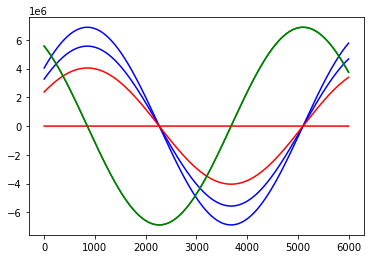

In [32]:
plt.plot([i for i in range(6000)], [S1[i][0] for i in range(6000)],color='b')
plt.plot([i for i in range(6000)], [S2[i][0] for i in range(6000)],color='b')
plt.plot([i for i in range(6000)], [S1[i][1] for i in range(6000)],color='r')
plt.plot([i for i in range(6000)], [S2[i][1] for i in range(6000)],color='r')
plt.plot([i for i in range(6000)], [S1[i][2] for i in range(6000)],color='g')
plt.plot([i for i in range(6000)], [S2[i][2] for i in range(6000)],color='g')
# plt.plot([i for i in range(6000)], [Dst[i] for i in range(6000)], color='y')

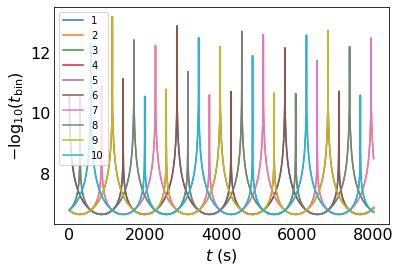

In [7]:
import math
import matplotlib.pyplot as plt 

T_big = math.floor(8000)
dT = 0.1
bigsteps = math.floor(T_big/dT)


for i in range(1,11):
    c = np.array([])
    for t in range(bigsteps):
        if data[t]['[0, '+str(i)+']']['[1, '+str(i)+']']>0:
            c = np.append(c, -math.log10(data[t]['[0, '+str(i)+']']['[1, '+str(i)+']']))
        else:
            c = np.append(c,0)
    if i<6:    
        plt.plot([i*dT for i in range(bigsteps)], c)
    else:
        plt.plot([i*dT for i in range(bigsteps)], c)
# plt.xlim(2000,2500)
plt.xlabel(r'$t$ (s)', fontsize=16)
plt.ylabel(r'$-\log_{10}(t_{\rm bin})$', fontsize=16)
# plt.ylim(9,)
plt.legend(['1','2','3','4','5','6','7','8','9','10'])
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=16)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=16)
plt.savefig('prec_conj_0_1.pdf')

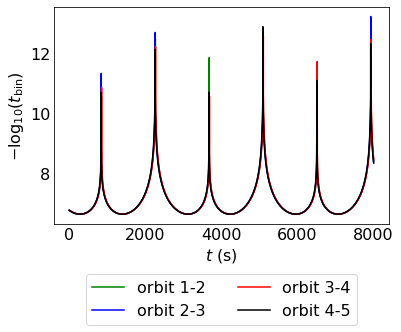

In [9]:
import math
import matplotlib.pyplot as plt 

T_big = math.floor(8000)
dT = 0.1
bigsteps = math.floor(T_big/dT)

a = np.array([])
b = np.array([])
c = np.array([])
d = np.array([])

for t in range(bigsteps):
        
    if data[t]['[0, 1]']['[1, 1]']>0:
        a = np.append(a, -math.log10(data[t]['[1, 2]']['[2, 2]']))
    else:
        a = np.append(a,0)

    if data[t]['[1, 1]']['[2, 1]']>0:
        b = np.append(b, -math.log10(data[t]['[2, 2]']['[3, 2]']))
    else:
        b = np.append(b,0)
        
    if data[t]['[2, 1]']['[3, 1]']>0:
        c = np.append(c, -math.log10(data[t]['[0, 2]']['[1, 2]']))
    else:
        c = np.append(c,0)
        
    if data[t]['[3, 1]']['[4, 1]']>0:
        d = np.append(d, -math.log10(data[t]['[3, 2]']['[4, 2]']))
    else:
        d = np.append(d,0)
plt.plot([i*dT for i in range(bigsteps)], a, color= 'g')
plt.plot([i*dT for i in range(bigsteps)], b, color= 'b')
plt.plot([i*dT for i in range(bigsteps)], c, color= 'r')
plt.plot([i*dT for i in range(bigsteps)], d, color= 'black')
# plt.xlim(2200,2325)
plt.xlabel(r'$t$ (s)', fontsize=16)
plt.ylabel(r'$-\log_{10}(t_{\rm bin})$', fontsize=16)
# plt.ylim(9,)
plt.legend(['orbit 1-2', 'orbit 2-3', 'orbit 3-4', 'orbit 4-5'], ncol = 2, fontsize=16, bbox_to_anchor=(0.5,-0.5), loc='lower center')
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=16)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=16)

plt.savefig('prec_conj_pair1_all_orbits.pdf', bbox_inches='tight')

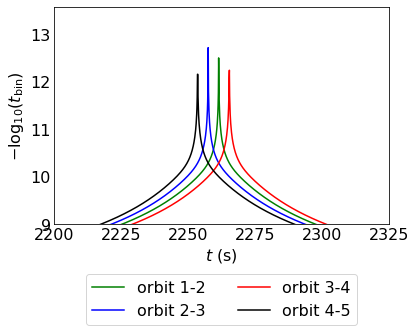

In [10]:
import math
import matplotlib.pyplot as plt 

T_big = math.floor(8000)
dT = 0.1
bigsteps = math.floor(T_big/dT)

a = np.array([])
b = np.array([])
c = np.array([])
d = np.array([])

for t in range(bigsteps):
        
    if data[t]['[0, 1]']['[1, 1]']>0:
        a = np.append(a, -math.log10(data[t]['[1, 2]']['[2, 2]']))
    else:
        a = np.append(a,0)

    if data[t]['[1, 1]']['[2, 1]']>0:
        b = np.append(b, -math.log10(data[t]['[2, 2]']['[3, 2]']))
    else:
        b = np.append(b,0)
        
    if data[t]['[2, 1]']['[3, 1]']>0:
        c = np.append(c, -math.log10(data[t]['[0, 2]']['[1, 2]']))
    else:
        c = np.append(c,0)
        
    if data[t]['[3, 1]']['[4, 1]']>0:
        d = np.append(d, -math.log10(data[t]['[3, 2]']['[4, 2]']))
    else:
        d = np.append(d,0)
plt.plot([i*dT for i in range(bigsteps)], a, color= 'g')
plt.plot([i*dT for i in range(bigsteps)], b, color= 'b')
plt.plot([i*dT for i in range(bigsteps)], c, color= 'r')
plt.plot([i*dT for i in range(bigsteps)], d, color= 'black')
plt.xlim(2200,2325)
plt.xlabel(r'$t$ (s)', fontsize=16)
plt.ylabel(r'$-\log_{10}(t_{\rm bin})$', fontsize=16)
plt.ylim(9,)
plt.legend(['orbit 1-2', 'orbit 2-3', 'orbit 3-4', 'orbit 4-5'], ncol = 2, fontsize=16, bbox_to_anchor=(0.5,-0.5), loc='lower center')
plt.tick_params(axis="x", bottom=False, top=False,
               length=4, width=1.5, direction="in", labelsize=16)
plt.tick_params(axis="y", left=False, right=False,
               length=0, width=1.5, direction="in", labelsize=16)

plt.savefig('prec_conj_pair1_all_orbits_zoomed.pdf', bbox_inches='tight')

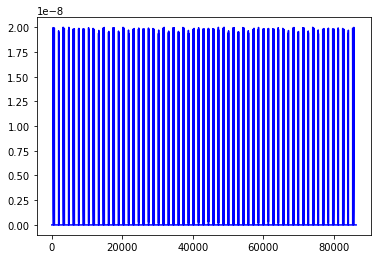

In [56]:
a = np.array([])
for t in range(bigsteps):
    a = np.append(a, data[t]['[1, 5]']['[2, 5]'])
# b = np.array([])
# for t in range(bigsteps):
#     b = np.append(b, data[t]['[5, 6]']['[6, 6]'])
plt.plot([i for i in range(bigsteps)], a, color= 'b')
# plt.plot([i for i in range(bigsteps)], b, color= 'r')

0
10000
20000
30000
40000
50000
60000
70000
80000


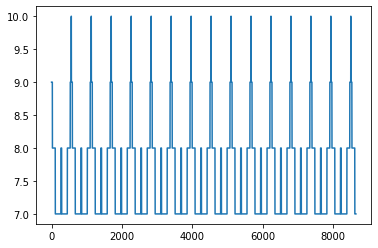

In [29]:
import numpy as np
import math 
import random
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm

T_big = math.floor(int(86400/10))
dT = 0.1
bigsteps = math.floor(T_big/dT)-1
min_prec = np.array([0]*int(bigsteps))

for t in range(int(bigsteps)):
    if t%10000==0:
        print(t)
        
    max_prec_orb=np.array([0]*(n_orb-1))
    
    for i in list(data[t].keys()):
        k = int(list(i)[1]) #orb number sat1
        if len(list(i))==6:
            l = int(list(i)[4]) #sat number sat1
        else:
            l = int(list(i)[4]+list(i)[5])
        
        for j in list(data[t][i].keys()):
            m = int(list(j)[1]) #orb number sat2
            if len(list(j))==6:
                n = int(list(j)[4]) #sat number sat2
            else:
                n = int(list(j)[4]+list(j)[5])
            
            if k<n_orb-1 and m==(k+1) and data[t][i][j]>0:
                prec = -math.log10(data[t][i][j])
                if prec>max_prec_orb[k]:
                    max_prec_orb[k] = prec
#                     print(max_prec_orb[k])
    
#     print(max_prec_orb)
    min_prec[t] = np.min(max_prec_orb)

# for i in range(int(bigsteps)):
#     if min_prec[i]<9:
#         min_prec[i]=0
plt.plot([i*dT for i in range(int(bigsteps))], min_prec)

In [88]:
#continental US with intersatellite comm.

import numpy as np
import math 
import random
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm
import copy

def generate_rotation(axis, angle):

    # Last modified: 13 March 2019

    """
    Generates the rotation matrix about the given axis (unit vector in Cartesian coordinates) by the given angle.
    """

    # Generators of the SO(3) rotations
    Lx = np.matrix([[0, 0, 0], [0, 0, -1], [0, 1, 0]])
    Ly = np.matrix([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
    Lz = np.matrix([[0, -1, 0], [1, 0, 0], [0, 0, 0]])

    n1 = axis[0]
    n2 = axis[1]
    n3 = axis[2]

    L = n1 * Lx + n2 * Ly + n3 * Lz

    return np.matrix(expm(angle * L))

def evolve_vector(init_point, axis, omega, T):

    """
    Performs rotation of a given initial point (init_point, in Cartesian coordinates) by the given axis
    (unit vector in Cartesian coordinates) at a given rotation speed (omega) for a time T (starting at t = 0).
    """

    init_point = np.matrix(init_point).H

    R = generate_rotation(axis, omega * T)
    point_t = R * init_point

    point_t_x = np.array(point_t[0])[0][0]
    point_t_y = np.array(point_t[1])[0][0]
    point_t_z = np.array(point_t[2])[0][0]

    return [point_t_x, point_t_y, point_t_z]

def generate_point(R, theta, phi):

    """
    Generates (in Cartesian coordinates) the point in 3D specified by
    the spherical coordinates R, theta, phi
    Here, phi is the azimuthal angle (positive going counter-clockwise from the positive x-axis), and
    theta is the polar angle (positive going down from the z-axis)
    """

    return [R * np.sin(theta) * np.cos(phi), R * np.sin(theta) * np.sin(phi), R * np.cos(theta)]

def dst(a, b):
    
    return ((a[0]-b[0])**2 + (a[1]-b[1])**2 + (a[2]-b[2])**2)**0.5

def eta(L, h, r, R, eff):
    lam = 810e-9;
    eta_zen = 0.5;
    sigma = 0;

    secZ = 1 / ((h / L) - (L**2 - h**2) / (2 * R * L));

    eta_atm2 = eta_zen**secZ;

    w0 = .8 * r;  # initial waist of optical beam

    theta_d = lam / (np.pi * w0);  # beam divergence angle

    wL = (w0**2 + (theta_d**2 + sigma**2) * (L**2))**0.5;  # beam waist at receiving OGS, a distance L away from transmitter

    eta_sg = 1 - np.exp(-2 * R**2 / wL**2);  # diffraction-lim transmittance

    efficiency = eta_sg * eta_atm2 * eff;
    
    return efficiency

def eta_sat(L, h, r, R, eff):
    
    lam = 810e-9;
    sigma = 0;

    secZ = 1 / ((h / L) - (L**2 - h**2) / (2 * R * L));

    w0 = .8 * r;  # initial waist of optical beam

    theta_d = lam / (np.pi * w0);  # beam divergence angle

    wL = (w0**2 + (theta_d**2 + sigma**2) * (L**2))**0.5;  # beam waist at receiving OGS, a distance L away from transmitter

    eta_sg = 1 - np.exp(-2 * R**2 / wL**2);  # diffraction-lim transmittance

    efficiency = eta_sg * eff;
    
    return efficiency

def generate_sat_ring(num_sats, R, h, theta, phi, offset, multiple_alt=False):
    # Last modified: 3 October 2019

    """
    Generates the satellite architecture consisting of n rings at azimuthal
    angles 'phi'(in degrees) and polar angles 'theta'(in degrees) stored in lists of length
    n each.  There are num_sats equally-spaced satellites in each ring.  R is
    the radius of the earth (in meters), and h is the altitude of the
    satellites (in meters)
  Parameters
  ----------
  num_sats:
      number of satellites in each ring
  R:
      Repition rate of the source in ebits / sec
  h:
      altitude for the satellite rings (in meters), If multiple_alt = True, then h should be a list of altitudes.
  phi:
      list of azimuthal angles (longitudes in degrees) at which the polar rings are set up.
  theta:
      list of angles (in degrees) through which the polar rings are rotated about the x-axis (latitude rotation)
      to make them tilted.
  offset:
      list of initial offset polar angles (latitudes in degrees) at which the rings are set up.
  Returns
  -------
  S:
      dictionary containing positions of the satellites and their orbit axes.
  """
    S = {}
    for i in range(len(theta)):
        theta[i] = theta[i] * np.pi / 180
        offset[i] = offset[i] * np.pi / 180
        
        phi[i] = phi[i] * np.pi / 180
        S[i] = {}
        count1 = 0
        
        for k in range(0, num_sats):
            count1 += 1
            S[i][count1] = generate_point(R + h, 2 * k * np.pi / num_sats + offset[i], np.pi/2-phi[i])
            rot_pt = generate_rotation([1, 0, 0], np.pi/2-theta[i]) * np.matrix(S[i][count1]).H
            S[i][count1] = [np.array(rot_pt[0])[0][0], np.array(rot_pt[1])[0][0], np.array(rot_pt[2])[0][0]]

        S[i]['axis'] = [np.sin(theta[i]) * np.cos(phi[i]), np.sin(theta[i]) * np.sin(phi[i]), np.cos(theta[i])]

    return S

def lineseg_dist(p, a, b):

    # normalized tangent vector
    np.seterr(divide='ignore', invalid='ignore')
    d = np.divide(b - a, np.linalg.norm(b - a))

    # signed parallel distance components
    s = np.dot(a - p, d)
    t = np.dot(p - b, d)

    # clamped parallel distance
    h = np.maximum.reduce([s, t, 0])

    # perpendicular distance component
    c = np.cross(p - a, d)

    return np.hypot(h, np.linalg.norm(c))

#constants

c = 2.9978e8
R = 6371e3
h = 1000e3
G = 6.67408e-11
M = 5.972e24
om = (G*M/(R+h)**3)**0.5
Om = 2*np.pi/24/3600

# protocol run parameters

noise_rate_gs = 1e5
noise_rate_sat = 1e5
pair_rate = 1e7
dt = 1e-9
N_c = 10

T_big = math.floor(86400/2)
dT = 1
bigsteps = math.floor(T_big/dT)


#satellite constellation
n_sat = 10
n_rings = 1
# orientation angles for rings of satellites
theta = [90]*n_rings
offset = [0]*n_rings #np.linspace(0,1,n_rings)
phi = [0]#np.linspace(0,180,n_rings)

# generating the satellite constellation
S_0 = generate_sat_ring(n_sat, R, h, theta, phi, offset, multiple_alt=False)


gs1_0 = generate_point(R, (90-40.7128)*np.pi/180, 65.0060*np.pi/180) # NY 40.7128° N, 74.0060° W
gs2_0 = generate_point(R, (90-33.7490)*np.pi/180, 84.3880*np.pi/180) # ATL 33.7490° N, 84.3880° W
gs3_0 = generate_point(R, (90-34.0522)*np.pi/180, 118.2437*np.pi/180) # LA 34.0522° N, 118.2437° W
gs4_0 = generate_point(R, (90-47.6062)*np.pi/180, 122.3321*np.pi/180) # SEA 47.6062° N, 122.3321° W
gs5_0 = generate_point(R, (90+53.4728)*np.pi/180, 67.4260*np.pi/180) # RIG 53.4728° S, 67.4260° W

GS_0 = [gs1_0, gs2_0, gs3_0, gs4_0, gs5_0]
axis_earth = np.array([0,0,1]) #z-axis
n_cities = 5
GS = copy.deepcopy(GS_0)
S = copy.deepcopy(S_0)

#dynamics
def sat_sat_links(t):
    if t%500 == 0:
        print('time'+str(t*dT)+'of'+str(T_big))
    Data = {}
    
    for k in range(n_cities):
        gs_label = str(k)
        Data[gs_label] = {}
        GS[k] = evolve_vector(GS_0[k], axis_earth, Om, t*dT)
        v_gs = np.cross(GS[k], Om*axis_earth)
        for i in list(S.keys()):
            ring_axis = S[i]['axis']
            for j in list(S[i].keys()):
                if j =='axis':
                    continue
                sat_label = str([i,j])
                S[i][j] = evolve_vector(S_0[i][j], ring_axis, om, t*dT)
                ang = np.dot(np.subtract(S[i][j],GS[k]),GS[k])/np.linalg.norm(GS[k])/np.linalg.norm(np.subtract(S[i][j],GS[k]))
                v_sat = np.cross(S[i][j], om*np.array(ring_axis))
                v_rel_rad = np.dot(np.subtract(v_sat, v_gs), np.subtract(S[i][j], GS[k])/np.linalg.norm(np.subtract(S[i][j], GS[k])))
                if ang>1e-10:
                    Data[gs_label][sat_label] = -math.log10(N_c*abs(v_rel_rad)/c/pair_rate/eta(dst(S[i][j], GS[k]), h, 0.6, 0.1, 0.25))
                
    return Data

t0  = time.time()    
data = Parallel(n_jobs=25)(delayed(sat_sat_links)(t) for t in range(bigsteps))
print('game over')
print(time.time() - t0)


KeyboardInterrupt: 

In [269]:
prec_12 = np.array([0.]*bigsteps)
city1 = '0'
city2 = '4'
for t in range(bigsteps):
    prec1 = 0.
    prec2 = 0.
    for i in list(data[t][city1].keys()):
        if data[t][city1][i]>prec1:
            prec1 = data[t][city1][i]
    for j in list(data[t][city2].keys()):
        if data[t][city2][j]>prec1:
            prec2 = data[t][city2][j]
    prec_12[t] = prec1#min([prec1, prec2])
    if prec_12[t]<10:
        prec_12[t] = 0
print(np.size(np.where(prec_12!=0))/bigsteps*100)    

7.604166666666666


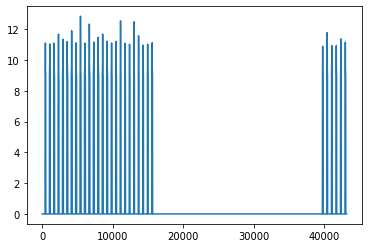

In [273]:
import numpy as np
import math 
import random
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm

bigsteps = math.floor(T_big/dT)

plt.plot([i for i in range(bigsteps)], prec_12)
# plt.xlim(1000,2000)

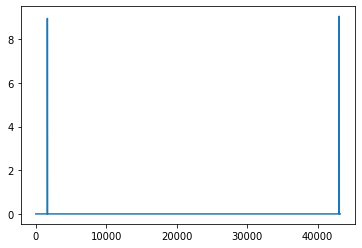

In [264]:
import numpy as np
import math 
import random
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm

bigsteps = math.floor(T_big/dT)

plt.plot([i for i in range(bigsteps)], prec_12)

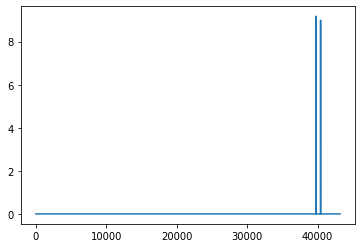

In [266]:
import numpy as np
import math 
import random
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm

bigsteps = math.floor(T_big/dT)

plt.plot([i for i in range(bigsteps)], prec_12)

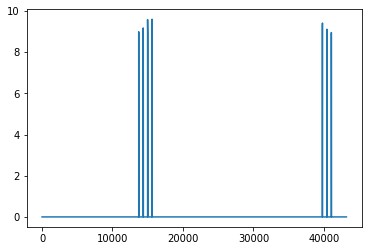

In [268]:
import numpy as np
import math 
import random
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm

bigsteps = math.floor(T_big/dT)

plt.plot([i for i in range(bigsteps)], prec_12)